Sel 1: Import Library & Deteksi Otomatis Seluruh File

In [6]:
# SEL 1: Import Library & Deteksi Semua File Gambar
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Mengambil semua file gambar berformat .jpg
image_files = sorted([f for f in os.listdir('.') if f.endswith('.jpg')])

print("="*60)
print(f"Berhasil menemukan {len(image_files)} gambar ijazah di direktori Colab:")
print("="*60)
for idx, fname in enumerate(image_files, 1):
    print(f"{idx}. {fname}")

Berhasil menemukan 9 gambar ijazah di direktori Colab:
1. 01_HighQuality_Enhanced (1).jpg
2. 02_LowContrast (1).jpg
3. 03_Blurred (1).jpg
4. 04_HighNoise (1).jpg
5. 05_LowResolution_Upsampled (1).jpg
6. 06_Faded_Underexposed (1).jpg
7. 07_ColorShift_WarmTint (1).jpg
8. 08_JPEGCompression_Artifacts (1).jpg
9. 09_CombinedDegradation (1).jpg


Sel 2: Tampilkan Seluruh Gambar Asli (9 Ijazah)

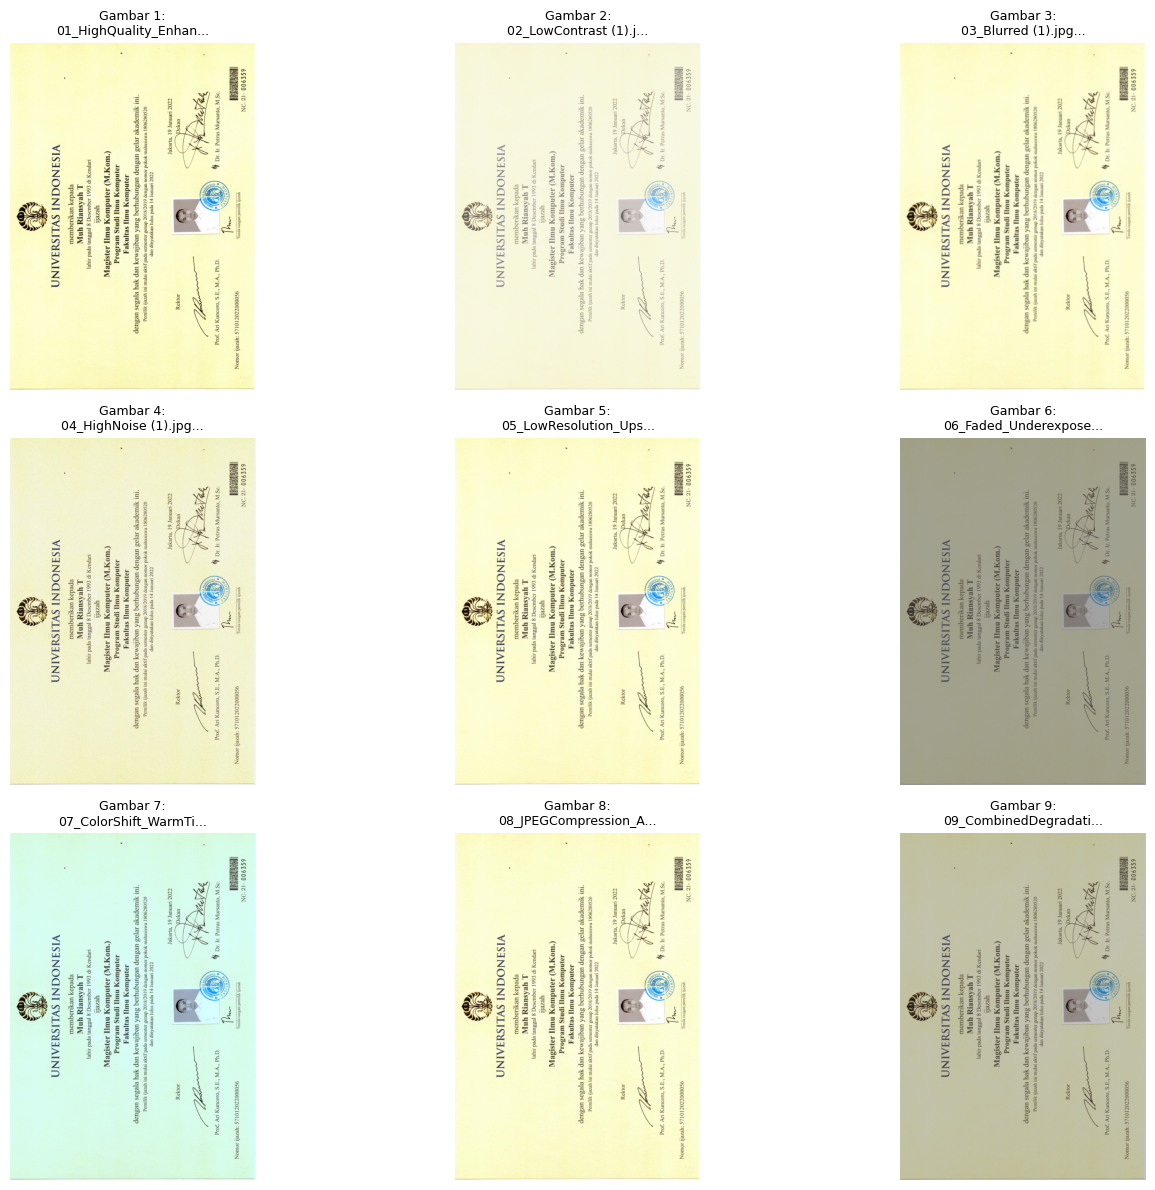

In [7]:
# SEL 2: Visualisasi Seluruh Citra Asli
plt.figure(figsize=(15, 12))

for i, file_name in enumerate(image_files):
    img = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Gambar {i+1}:\n{file_name[:20]}...", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

Sel 3: Crop Area Tanda Tangan Dekan pada Semua Gambar

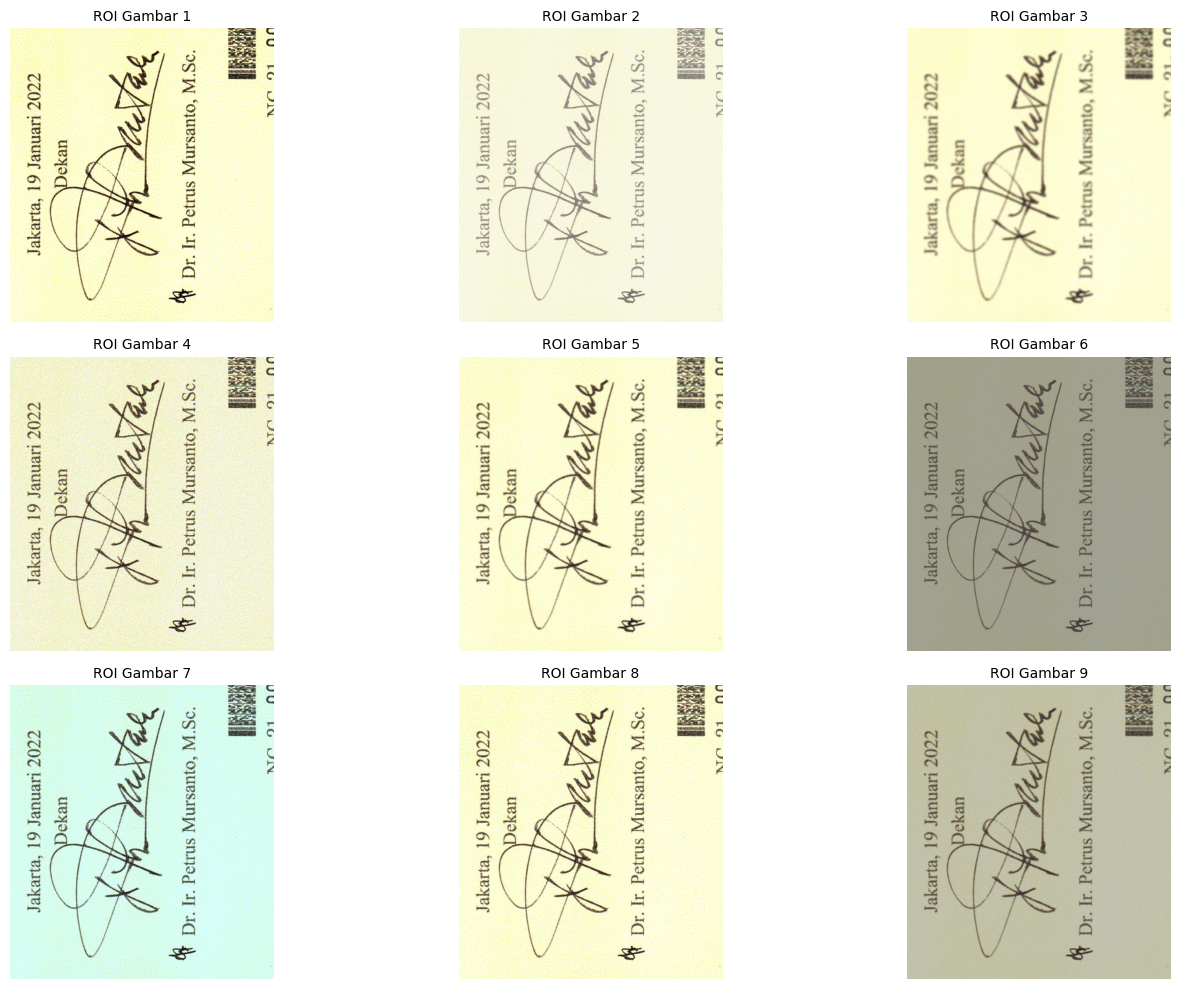

In [8]:
# SEL 3: Cropping ROI Tanda Tangan Dekan (Seluruh Gambar)
rois = []
grays = []

plt.figure(figsize=(15, 10))

for i, file_name in enumerate(image_files):
    img = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Koordinat crop lokasi tanda tangan Dekan (Kanan Atas)
    y_start, y_end = int(h * 0.12), int(h * 0.38)
    x_start, x_end = int(w * 0.62), int(w * 0.95)

    roi = img_rgb[y_start:y_end, x_start:x_end]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

    rois.append(roi)
    grays.append(gray)

    plt.subplot(3, 3, i + 1)
    plt.imshow(roi)
    plt.title(f"ROI Gambar {i+1}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

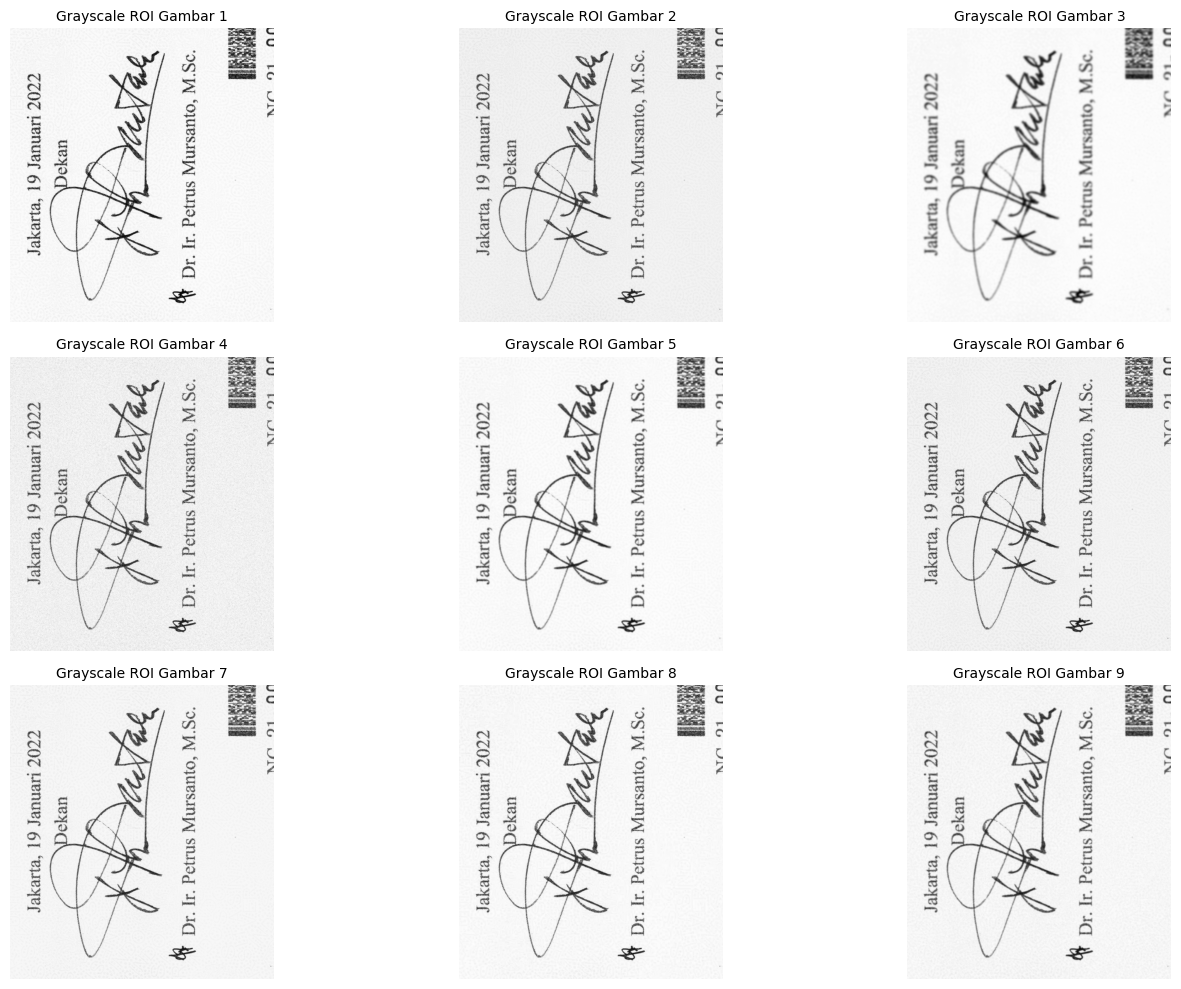

In [18]:
# SEL TAMBAHAN: Display Grayscale Khusus untuk Laporan
plt.figure(figsize=(15, 10))

for i, file_name in enumerate(image_files):
    # Mengambil gambar grayscale yang sudah diproses di Sel 3
    gray_img = grays[i]

    plt.subplot(3, 3, i + 1)
    # Gunakan cmap='gray' untuk menampilkan gambar derajat keabuan murni
    plt.imshow(gray_img, cmap='gray')
    plt.title(f"Grayscale ROI Gambar {i+1}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Sel 4: Penerapan Perbandingan Thresholding (Global, Otsu, Adaptive)                                                   
Membandingkan metode Global Thresholding, Otsu, dan Adaptive Thresholding pada seluruh sampel.   

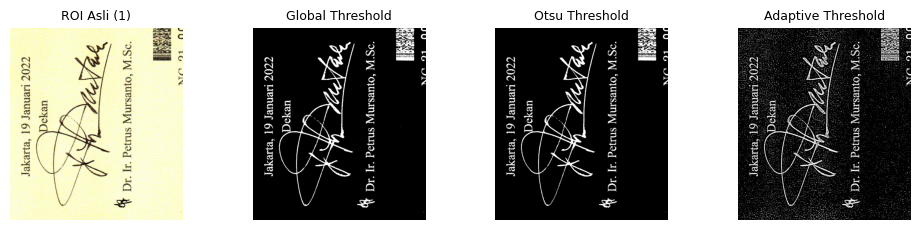

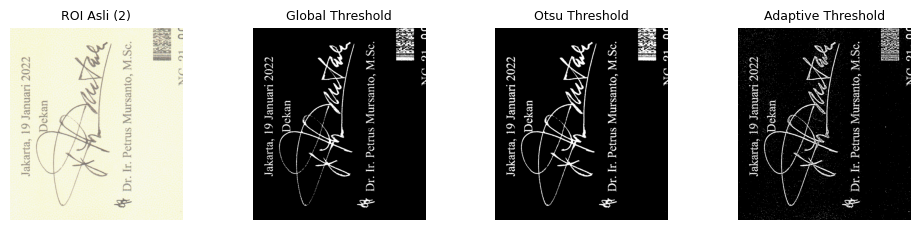

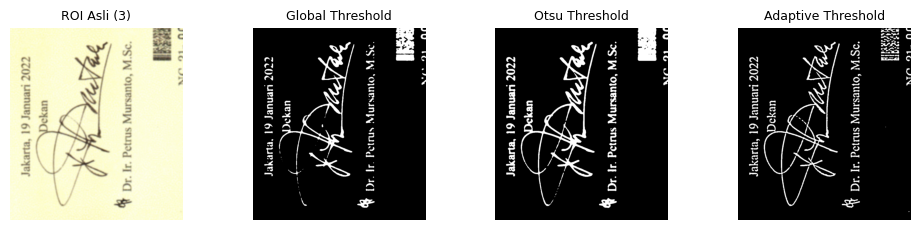

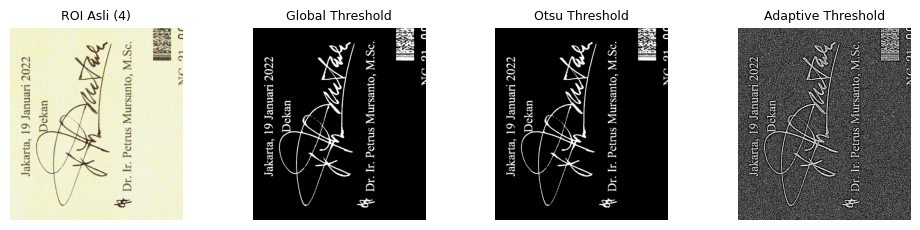

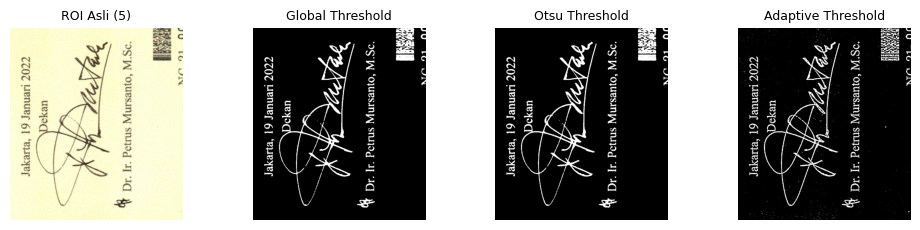

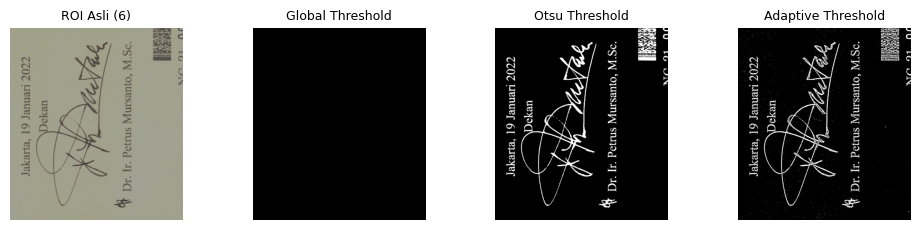

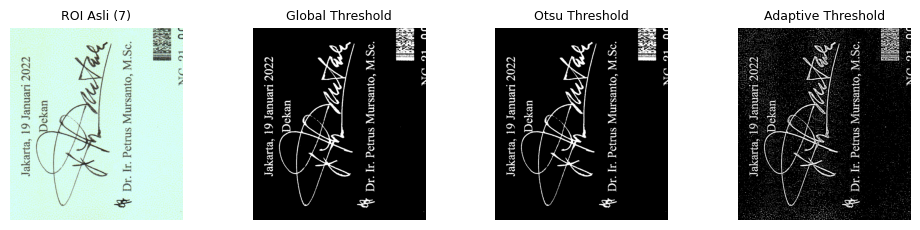

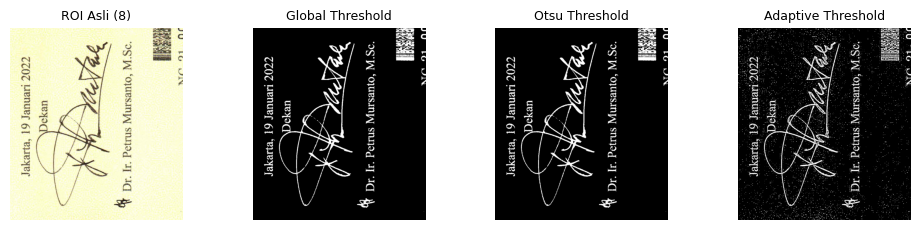

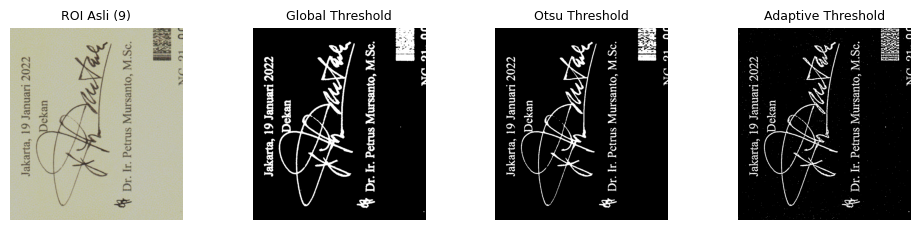

In [9]:
# SEL 4: Perbandingan 3 Metode Thresholding
otsu_results = []

for i, file_name in enumerate(image_files):
    gray = grays[i]

    # 1. Global Thresholding (Nilai Ambang = 180)
    _, thresh_global = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

    # 2. Otsu's Thresholding (Otomatis)
    _, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    otsu_results.append(thresh_otsu)

    # 3. Adaptive Thresholding (Lokal)
    thresh_adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 15, 5
    )

    # Tampilkan perbandingan
    plt.figure(figsize=(12, 2.5))

    plt.subplot(1, 4, 1)
    plt.imshow(rois[i])
    plt.title(f"ROI Asli ({i+1})", fontsize=9)
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(thresh_global, cmap='gray')
    plt.title("Global Threshold", fontsize=9)
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(thresh_otsu, cmap='gray')
    plt.title("Otsu Threshold", fontsize=9)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(thresh_adaptive, cmap='gray')
    plt.title("Adaptive Threshold", fontsize=9)
    plt.axis('off')

    plt.show()

Sel 5: Operasi Morfologi (Opening & Closing)                
Membersihkan bintik derau (noise) dan menyambungkan coretan tanda tangan yang terputus pada seluruh gambar.

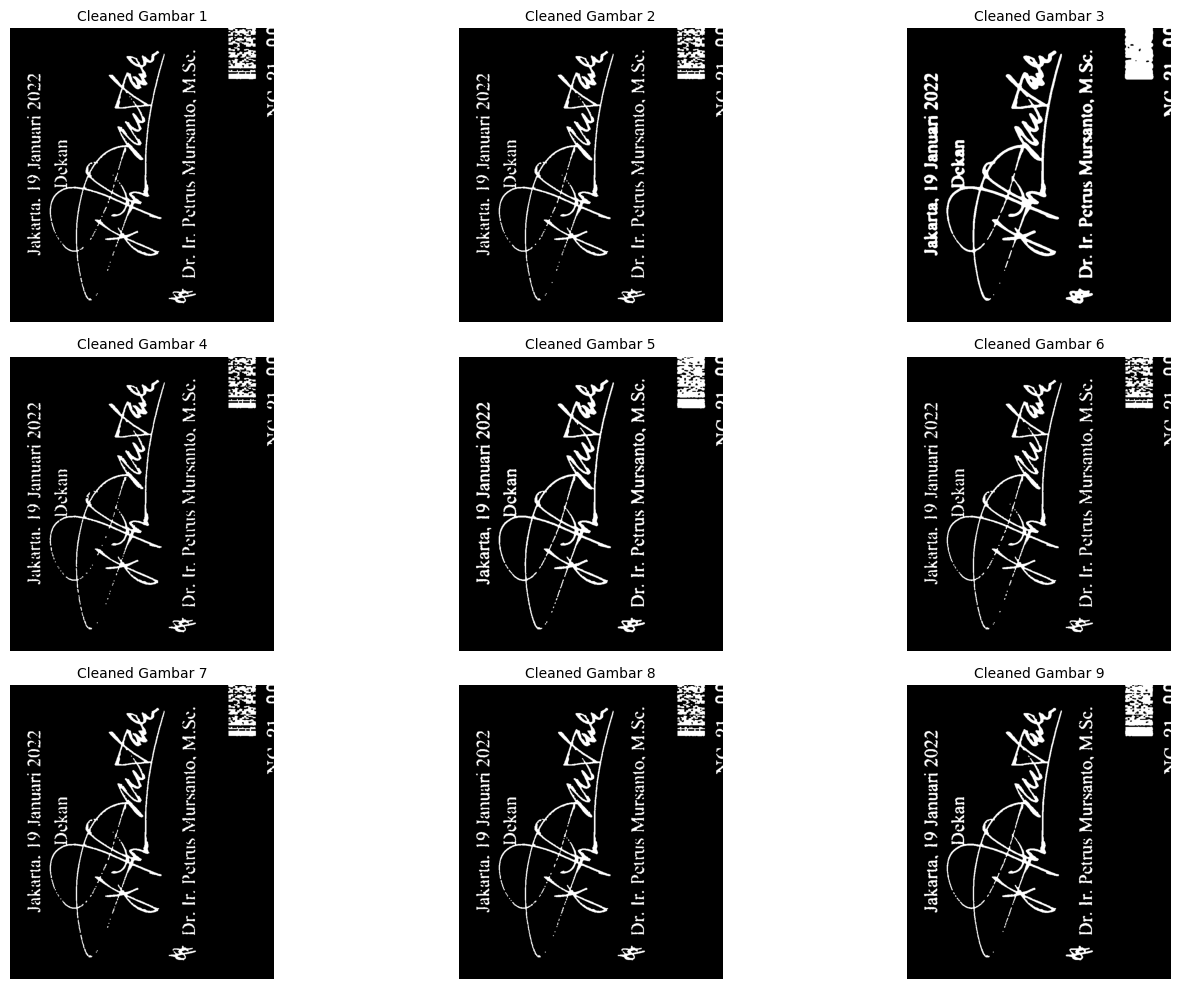

In [10]:
# SEL 5: Operasi Morfologi pada Hasil Threshold Otsu
cleaned_results = []
kernel = np.ones((3, 3), np.uint8)

plt.figure(figsize=(15, 10))

for i, file_name in enumerate(image_files):
    thresh = otsu_results[i]

    # Morphological Opening & Closing
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    cleaned_results.append(cleaned)

    plt.subplot(3, 3, i + 1)
    plt.imshow(cleaned, cmap='gray')
    plt.title(f"Cleaned Gambar {i+1}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Sel 6: Hitung Piksel Foreground & Klasifikasi Keputusan     
Hitung kuantitatif jumlah piksel putih (foreground) dan penentuan otomatis status SIGNATURE PRESENT atau SIGNATURE ABSEN

In [11]:
# SEL 6: Klasifikasi dan Tabel Ringkasan
THRESHOLD_PIXELS = 2000  # Batas minimum jumlah piksel tanda tangan

print("="*80)
print(f"{'NO':<4} | {'NAMA FILE IJAZAH':<38} | {'PIKSEL FOREGROUND':<18} | {'STATUS DETEKSI':<15}")
print("="*80)

summary_results = []

for i, file_name in enumerate(image_files):
    cleaned_img = cleaned_results[i]
    pixel_count = cv2.countNonZero(cleaned_img)

    # Decision Rule
    if pixel_count > THRESHOLD_PIXELS:
        status = "SIGNATURE PRESENT"
    else:
        status = "SIGNATURE ABSENT"

    summary_results.append((file_name, pixel_count, status))
    print(f"{i+1:<4} | {file_name:<38} | {pixel_count:<18} | {status:<15}")

print("="*80)

NO   | NAMA FILE IJAZAH                       | PIKSEL FOREGROUND  | STATUS DETEKSI 
1    | 01_HighQuality_Enhanced (1).jpg        | 47897              | SIGNATURE PRESENT
2    | 02_LowContrast (1).jpg                 | 48412              | SIGNATURE PRESENT
3    | 03_Blurred (1).jpg                     | 76853              | SIGNATURE PRESENT
4    | 04_HighNoise (1).jpg                   | 46239              | SIGNATURE PRESENT
5    | 05_LowResolution_Upsampled (1).jpg     | 59329              | SIGNATURE PRESENT
6    | 06_Faded_Underexposed (1).jpg          | 49191              | SIGNATURE PRESENT
7    | 07_ColorShift_WarmTint (1).jpg         | 48526              | SIGNATURE PRESENT
8    | 08_JPEGCompression_Artifacts (1).jpg   | 49796              | SIGNATURE PRESENT
9    | 09_CombinedDegradation (1).jpg         | 56689              | SIGNATURE PRESENT


Sel 7: Visualisasi Hasil Akhir Komparatif (Selesai)          
Menampilkan perbandingan ROI asli dan hasil segmentasi biner akhir beserta label status keputusan.

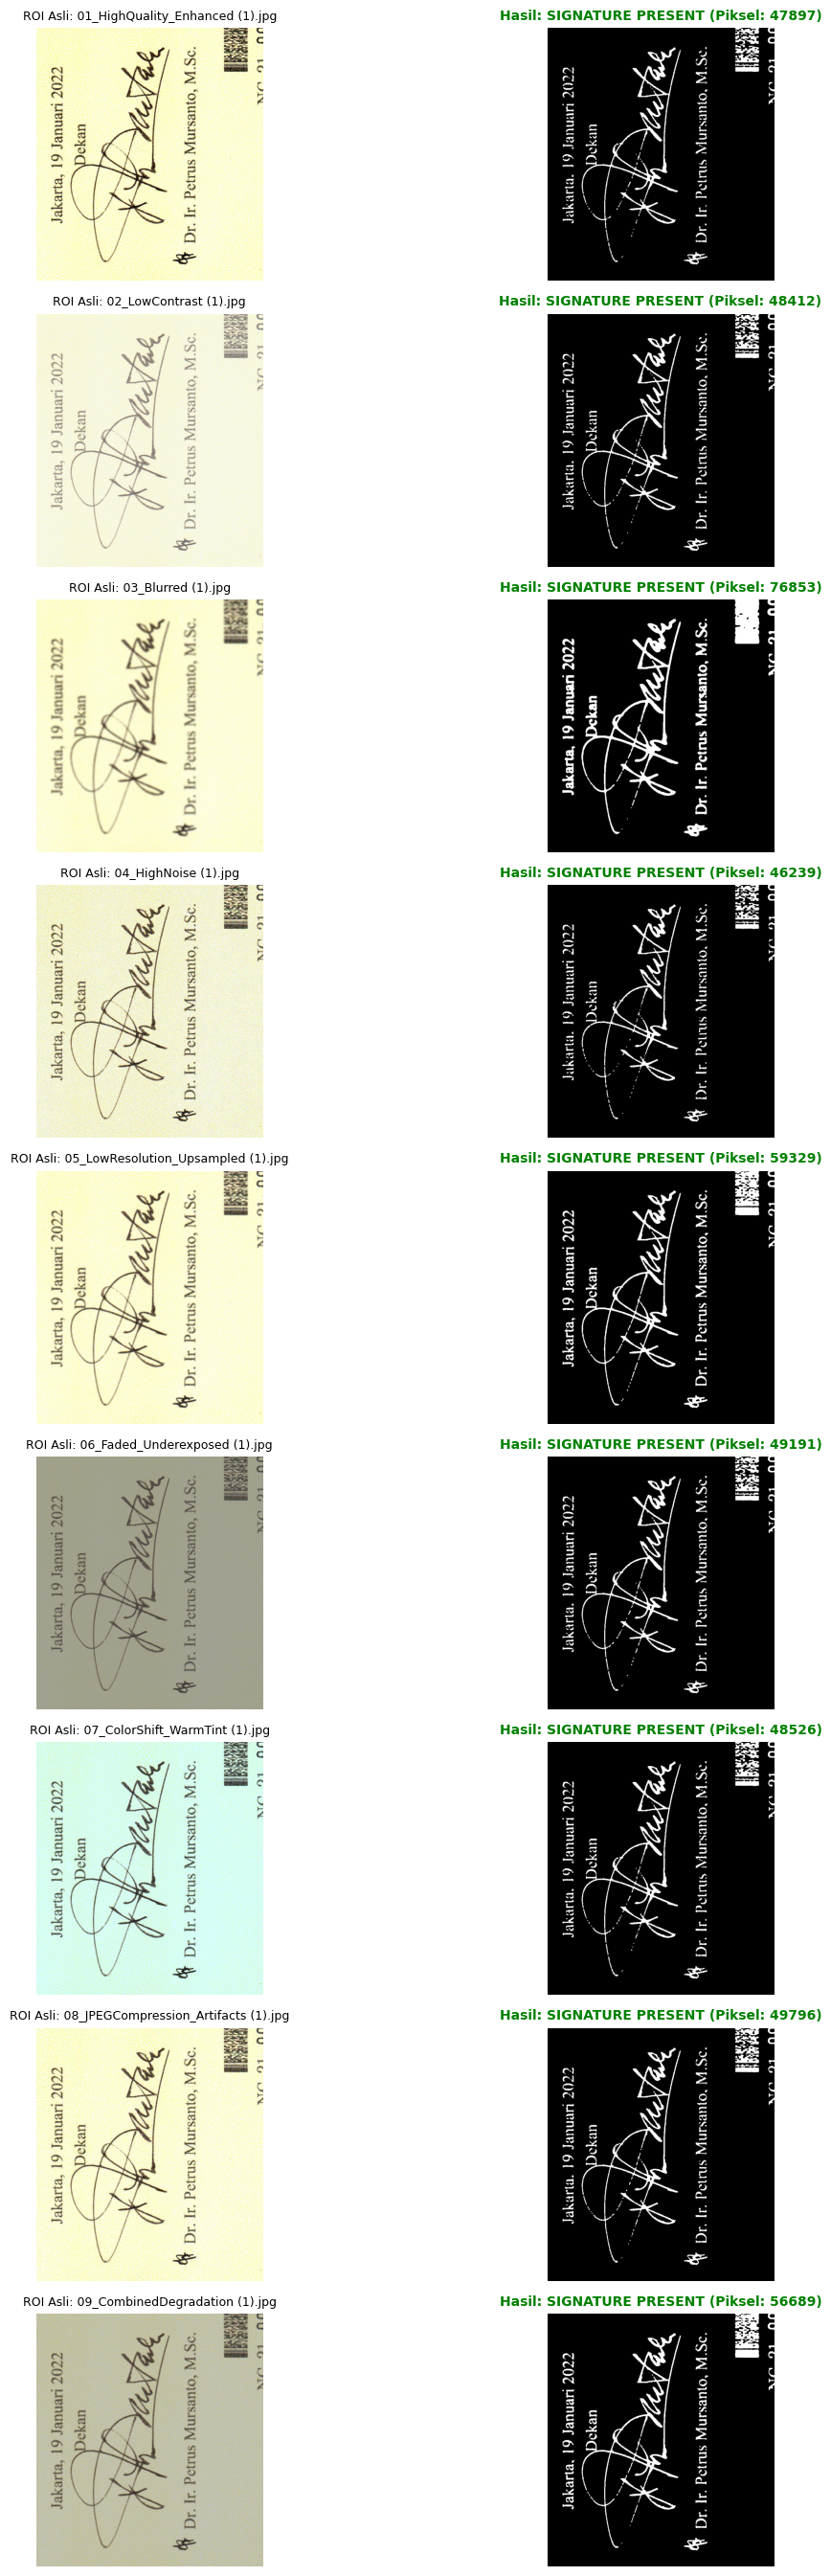

In [12]:
# SEL 7: Visualisasi Hasil Akhir
plt.figure(figsize=(14, 3 * len(image_files)))

for i, (file_name, pixel_count, status) in enumerate(summary_results):
    # Gambar ROI
    plt.subplot(len(image_files), 2, 2 * i + 1)
    plt.imshow(rois[i])
    plt.title(f"ROI Asli: {file_name}", fontsize=9)
    plt.axis('off')

    # Hasil Biner Tersegmentasi
    plt.subplot(len(image_files), 2, 2 * i + 2)
    plt.imshow(cleaned_results[i], cmap='gray')
    color = 'green' if status == 'SIGNATURE PRESENT' else 'red'
    plt.title(f"Hasil: {status} (Piksel: {pixel_count})", color=color, fontweight='bold', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Uji sistem pada beberapa citra yang memiliki tanda tangan dan beberapa yang tidak memiliki tanda tangan.

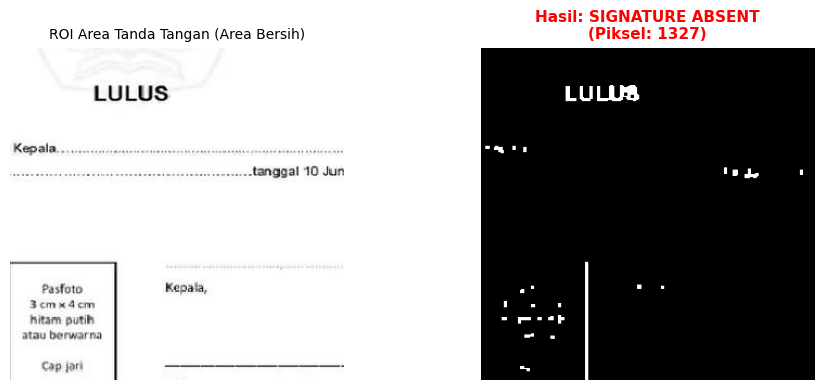

File: absent1.jpg | Total Piksel: 1327 | Status Akhir: SIGNATURE ABSENT


In [20]:
# SEL TAMBAHAN: Pengujian Khusus Citra Tanpa Tanda Tangan (absent1.jpg)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Muat gambar
img = cv2.imread('absent1.jpg')

# Pastikan gambar berhasil dimuat
if img is None:
    print("Error: File 'absent1.jpg' tidak ditemukan. Pastikan nama file sudah benar.")
else:
    # 2. Crop ROI lebih spesifik (fokus area tanda tangan, hindari bingkai kanan)
    # Sesuaikan rasio crop jika ukuran gambar berbeda
    h, w, _ = img.shape
    roi = img[int(h*0.55):int(h*0.85), int(w*0.35):int(w*0.75)]

    # 3. Grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # 4. Otsu Thresholding
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 5. Operasi Morfologi (Opening & Closing)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    # 6. Hitung Piksel Foreground
    pixel_count = cv2.countNonZero(cleaned)

    # 7. Decision Rule (Aturan Keputusan Baru dengan Threshold 2500)
    NEW_THRESHOLD = 2500
    if pixel_count > NEW_THRESHOLD:
        status = "SIGNATURE PRESENT"
        color = "green"
    else:
        status = "SIGNATURE ABSENT"
        color = "red"

    # 8. Visualisasi Hasil
    plt.figure(figsize=(10, 4))

    # Tampilkan ROI Asli
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title("ROI Area Tanda Tangan (Area Bersih)", fontsize=10)
    plt.axis('off')

    # Tampilkan Hasil Biner
    plt.subplot(1, 2, 2)
    plt.imshow(cleaned, cmap='gray')
    plt.title(f"Hasil: {status}\n(Piksel: {pixel_count})", color=color, fontweight='bold', fontsize=11)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"File: absent1.jpg | Total Piksel: {pixel_count} | Status Akhir: {status}")

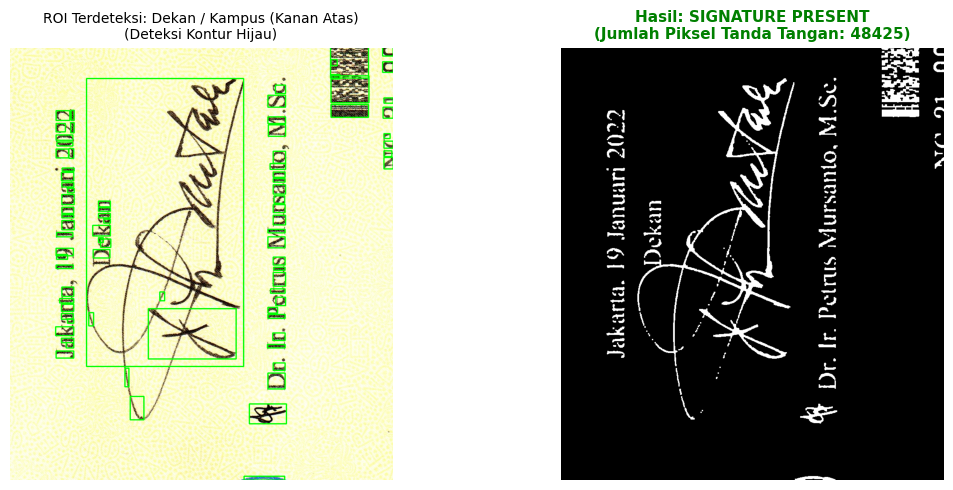

In [17]:
# KODE ALTERNATIF: Deteksi Tanda Tangan (SIGNATURE PRESENT) dengan Multi-ROI & Visualisasi Kontur
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_signature_advanced(img_path, threshold_pixels=1500):
    img = cv2.imread(img_path)
    if img is None:
        print(f"File {img_path} tidak ditemukan!")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Memeriksa 2 kandidat lokasi tanda tangan (Kanan Atas & Kanan Bawah)
    roi_candidates = [
        ("Dekan / Kampus (Kanan Atas)", int(h*0.12), int(h*0.40), int(w*0.60), int(w*0.95)),
        ("Kepala Sekolah / SD (Kanan Bawah)", int(h*0.68), int(h*0.88), int(w*0.52), int(w*0.90))
    ]

    best_roi = None
    best_cleaned = None
    max_pixels = 0
    selected_label = ""

    # Cari ROI yang memiliki jumlah piksel tanda tangan terbanyak
    for label, y1, y2, x1, x2 in roi_candidates:
        crop = img_rgb[y1:y2, x1:x2]
        gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

        # Otsu Thresholding & Morfologi
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel = np.ones((3, 3), np.uint8)
        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        pixels = cv2.countNonZero(cleaned)

        if pixels > max_pixels:
            max_pixels = pixels
            best_roi = crop.copy()
            best_cleaned = cleaned
            selected_label = label

    # Decision Rule
    status = "SIGNATURE PRESENT" if max_pixels > threshold_pixels else "SIGNATURE ABSENT"
    color_code = (0, 255, 0) if status == "SIGNATURE PRESENT" else (255, 0, 0)

    # Visualisasi Bounding Box pada Gambar Asli
    img_result = img_rgb.copy()
    if best_roi is not None:
        # Cari kontur tanda tangan untuk menggambar kotak hijau
        contours, _ = cv2.findContours(best_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) > 50:  # Abaikan bintik kecil
                x, y, bw, bh = cv2.boundingRect(cnt)
                # Sesuaikan koordinat relatif ROI ke citra asli
                # Menggambar kotak hijau di sekeliling goresan tanda tangan
                cv2.rectangle(best_roi, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

    # Plot Hasil
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(best_roi)
    plt.title(f"ROI Terdeteksi: {selected_label}\n(Deteksi Kontur Hijau)", fontsize=10)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(best_cleaned, cmap='gray')
    color_text = 'green' if status == "SIGNATURE PRESENT" else 'red'
    plt.title(f"Hasil: {status}\n(Jumlah Piksel Tanda Tangan: {max_pixels})", color=color_text, fontweight='bold', fontsize=11)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run Pengujian pada Sampel Ijazah Bertanda Tangan
detect_signature_advanced('01_HighQuality_Enhanced (1).jpg')